In [1]:
# @title Установка зависимостей
# Установка зависимостей
!pip install -q sentence-transformers scikit-learn matplotlib plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requ

In [2]:
# @title Импорт библиотек
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px

2025-11-29 09:39:38.918302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764409179.213876      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764409179.298558      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
# @title Тексты для построения эмбеддингов

texts = [
    "Кошка спит на диване.",
    "Кот отдыхает на мягкой мебели.",
    "Автомобиль едет по шоссе.",
    "Кот идёт по шоссе.",
    "Автомобиль стоит у магазина."
]

print("Исходные тексты:")
for i, t in enumerate(texts, 1):
    print(f"{i}. {t}")

Исходные тексты:
1. Кошка спит на диване.
2. Кот отдыхает на мягкой мебели.
3. Автомобиль едет по шоссе.
4. Кот идёт по шоссе.
5. Автомобиль стоит у магазина.


In [4]:
# @title Загрузка моделей эмбеддингов с поддержкой русского языка

print("\nЗагружаем модель эмбеддингов...")

# Используем ruBERT-tiny2
model = SentenceTransformer("cointegrated/rubert-tiny2")

print("Модель загружена!")


Загружаем модель эмбеддингов...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Модель загружена!


In [5]:
# @title Генерация эмбеддингов
print("\nГенерируем эмбеддинги...")

embeddings = model.encode(texts, normalize_embeddings=True)
print(f"Получено {len(embeddings)} эмбеддингов. Размерность: {embeddings.shape[1]}")


Генерируем эмбеддинги...
Получено 5 эмбеддингов. Размерность: 312


# Печать численных значений эмбеддингов и базовые метрики

In [6]:
#@title Печать численных значений эмбеддингов и базовые метрики

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [7]:
#@title Настройки печати векторов (чтобы было компактно и читабельно)
np.set_printoptions(precision=4, suppress=True, linewidth=120)

print("\nРазмерность эмбеддингов:", embeddings.shape)  # (кол-во_фраз, d)


Размерность эмбеддингов: (5, 312)


In [8]:
#@title 1) Печать самих векторов (первые N координат для краткости)
N = 12  # сколько координат показать из каждого вектора
for i, (text, vec) in enumerate(zip(texts, embeddings), 1):
    print(f"\n[{i}] «{text}»")
    print(f"   Норма L2: {np.linalg.norm(vec):.4f} (ожидаемо ~1.0, т.к. normalize_embeddings=True)")
    print(f"   Первые {N} координат вектора:")
    print(vec[:N])


[1] «Кошка спит на диване.»
   Норма L2: 1.0000 (ожидаемо ~1.0, т.к. normalize_embeddings=True)
   Первые 12 координат вектора:
[-0.0244 -0.0383  0.007  -0.0331 -0.0153  0.0204 -0.0317  0.0437  0.0734  0.0313 -0.0174  0.0258]

[2] «Кот отдыхает на мягкой мебели.»
   Норма L2: 1.0000 (ожидаемо ~1.0, т.к. normalize_embeddings=True)
   Первые 12 координат вектора:
[-0.085   0.0024  0.0277 -0.0341  0.0174  0.041   0.0099  0.0402  0.039  -0.0169 -0.0415  0.0184]

[3] «Автомобиль едет по шоссе.»
   Норма L2: 1.0000 (ожидаемо ~1.0, т.к. normalize_embeddings=True)
   Первые 12 координат вектора:
[-0.0673 -0.0639 -0.041  -0.0457  0.0207 -0.0038 -0.0251  0.0003  0.0341 -0.0505  0.0918  0.0175]

[4] «Кот идёт по шоссе.»
   Норма L2: 1.0000 (ожидаемо ~1.0, т.к. normalize_embeddings=True)
   Первые 12 координат вектора:
[-0.0712 -0.0075 -0.0167 -0.02    0.0227  0.0067  0.0204  0.0316  0.0137 -0.076   0.0727 -0.0084]

[5] «Автомобиль стоит у магазина.»
   Норма L2: 1.0000 (ожидаемо ~1.0, т.к. norma

In [9]:
#@title 2) Косинусные сходства (т.к. нормированы, это ~ скалярное произведение)
cos_sim = cosine_similarity(embeddings)
print("\nКосинусное сходство (чем ближе к 1 — тем семантически ближе):")
print(cos_sim)


Косинусное сходство (чем ближе к 1 — тем семантически ближе):
[[1.     0.7566 0.4649 0.5542 0.4691]
 [0.7566 1.     0.4955 0.5691 0.557 ]
 [0.4649 0.4955 1.     0.8903 0.7463]
 [0.5542 0.5691 0.8903 1.     0.6837]
 [0.4691 0.557  0.7463 0.6837 1.    ]]


In [10]:
#@title 3) Евклидовы (L2) расстояния (для нормированных векторов связаны с косинусом формулой: ||x-y||^2 = 2(1 - cosθ))
l2 = euclidean_distances(embeddings)
print("\nL2-дистанции (чем ближе к 0 — тем ближе вектора):")
print(l2)


L2-дистанции (чем ближе к 0 — тем ближе вектора):
[[0.     0.6978 1.0345 0.9443 1.0304]
 [0.6978 0.     1.0045 0.9283 0.9413]
 [1.0345 1.0045 0.     0.4685 0.7123]
 [0.9443 0.9283 0.4685 0.     0.7953]
 [1.0304 0.9413 0.7123 0.7953 0.    ]]


In [11]:
#@title 4) Топ-3 ближайших соседей по косинусу для каждой фразы (кроме самой себя)
top_k = 3
for i, text in enumerate(texts):
    # Сортируем индексы по убыванию сх-ва, пропускаем сам элемент (индекс i)
    order = np.argsort(-cos_sim[i])
    neighbors = [j for j in order if j != i][:top_k]
    print(f"\nТоп-{top_k} ближайших к [{i+1}] «{text}»:")
    for j in neighbors:
        print(f"  -> [{j+1}] «{texts[j]}» | cos={cos_sim[i, j]:.4f} | L2={l2[i, j]:.4f}")


Топ-3 ближайших к [1] «Кошка спит на диване.»:
  -> [2] «Кот отдыхает на мягкой мебели.» | cos=0.7566 | L2=0.6978
  -> [4] «Кот идёт по шоссе.» | cos=0.5542 | L2=0.9443
  -> [5] «Автомобиль стоит у магазина.» | cos=0.4691 | L2=1.0304

Топ-3 ближайших к [2] «Кот отдыхает на мягкой мебели.»:
  -> [1] «Кошка спит на диване.» | cos=0.7566 | L2=0.6978
  -> [4] «Кот идёт по шоссе.» | cos=0.5691 | L2=0.9283
  -> [5] «Автомобиль стоит у магазина.» | cos=0.5570 | L2=0.9413

Топ-3 ближайших к [3] «Автомобиль едет по шоссе.»:
  -> [4] «Кот идёт по шоссе.» | cos=0.8903 | L2=0.4685
  -> [5] «Автомобиль стоит у магазина.» | cos=0.7463 | L2=0.7123
  -> [2] «Кот отдыхает на мягкой мебели.» | cos=0.4955 | L2=1.0045

Топ-3 ближайших к [4] «Кот идёт по шоссе.»:
  -> [3] «Автомобиль едет по шоссе.» | cos=0.8903 | L2=0.4685
  -> [5] «Автомобиль стоит у магазина.» | cos=0.6837 | L2=0.7953
  -> [2] «Кот отдыхает на мягкой мебели.» | cos=0.5691 | L2=0.9283

Топ-3 ближайших к [5] «Автомобиль стоит у магазина.

#Визуализация


Снижаем размерность до 2D с помощью t-SNE...


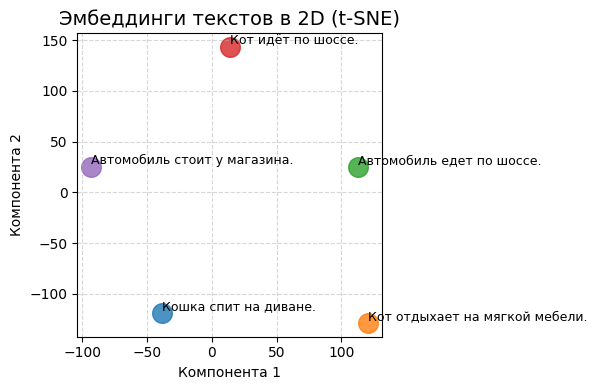

In [12]:
#@title Визуализация в 2D

print("\nСнижаем размерность до 2D с помощью t-SNE...")

tsne_2d = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
embeddings_2d = tsne_2d.fit_transform(embeddings)

plt.figure(figsize=(6, 4))

# Генерируем уникальный цвет для каждого текста
colors = cm.tab10(range(len(texts)))

for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, color=colors[i], s=200, alpha=0.8)
    # Отображаем сам текст (с ограничением длины для читаемости)
    label = texts[i]
    if len(label) > 50:
        label = label[:47] + "..."
    plt.text(x + 0.02, y + 0.02, label, fontsize=9, ha='left', va='bottom')

plt.title("Эмбеддинги текстов в 2D (t-SNE)", fontsize=14)
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
# @title Визуализация в 3D (Plotly )
print("\nСнижаем размерность до 3D...")

tsne_3d = TSNE(n_components=3, random_state=42, perplexity=min(30, len(embeddings)-1))
embeddings_3d = tsne_3d.fit_transform(embeddings)

print("Интерактивная 3D-визуализация:")

fig = px.scatter_3d(
    x=embeddings_3d[:, 0],
    y=embeddings_3d[:, 1],
    z=embeddings_3d[:, 2],
    text=[f"{i+1}: {t}" for i, t in enumerate(texts)],
    size_max=10,
    color = list(range(len(texts))),
    color_continuous_scale=["red", "blue"]
)

fig.update_traces(marker=dict(size=8), textposition="top center")
fig.update_layout(
    title="Эмбеддинги текстов в 3D (t-SNE)",
    scene=dict(
        xaxis_title="Компонента 1",
        yaxis_title="Компонента 2",
        zaxis_title="Компонента 3"
    ),
    width=800,
    height=600
)

fig.show()


Снижаем размерность до 3D...
Интерактивная 3D-визуализация:


#Подводим итоги

In [14]:
# @title Подводим итоги
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from IPython.display import display

print("\nКосинусное сходство между парами:")

sim_matrix = cosine_similarity(embeddings)

# Собираем данные
comparison_data = []
for i in range(len(texts)):
    for j in range(i + 1, len(texts)):
        sim = sim_matrix[i][j]
        comparison_data.append({
            "Текст A": texts[i],
            "Текст B": texts[j],
            "Сходство": round(sim, 3),
            "Вывод": "✅ Семантически близки" if sim > 0.7 else "❌ Семантически различны"
        })

# Создаём DataFrame
df_comparison = pd.DataFrame(comparison_data)

if not df_comparison.empty:
    pd.set_option('display.max_colwidth', 80)
    pd.set_option('display.width', None)
    pd.set_option('display.max_columns', None)

    display(df_comparison)
else:
    print("Нет пар для сравнения (нужно минимум 2 текста).")


Косинусное сходство между парами:


,Текст A,Текст B,Сходство,Вывод
0,Кошка спит на диване.,Кот отдыхает на мягкой мебели.,0.757,✅ Семантически близки
1,Кошка спит на диване.,Автомобиль едет по шоссе.,0.465,❌ Семантически различны
2,Кошка спит на диване.,Кот идёт по шоссе.,0.554,❌ Семантически различны
3,Кошка спит на диване.,Автомобиль стоит у магазина.,0.469,❌ Семантически различны
4,Кот отдыхает на мягкой мебели.,Автомобиль едет по шоссе.,0.496,❌ Семантически различны
5,Кот отдыхает на мягкой мебели.,Кот идёт по шоссе.,0.569,❌ Семантически различны
6,Кот отдыхает на мягкой мебели.,Автомобиль стоит у магазина.,0.557,❌ Семантически различны
7,Автомобиль едет по шоссе.,Кот идёт по шоссе.,0.890,✅ Семантически близки
8,Автомобиль едет по шоссе.,Автомобиль стоит у магазина.,0.746,✅ Семантически близки
9,Кот идёт по шоссе.,Автомобиль стоит у магазина.,0.684,❌ Семантически различны
